# ECCOv4r4 dataset errors on SciServer

This notebook documents the issues that are currently present with the ECCOv4r4 datasets on SciServer.

CMFW, June 2026

## Set up and load data

In [1]:
import seaduck
import pkgutil

print(seaduck.__file__)
print(getattr(seaduck, "__version__", "no version found"))

print([m.name for m in pkgutil.iter_modules(seaduck.__path__)])

/home/idies/mambaforge/envs/Oceanography/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/idies/mambaforge/envs/Oceanography/lib/python3.12/site-packages/seaduck/__init__.py
1.0.5
['eulerian', 'eulerian_budget', 'get_masks', 'kernel_weight', 'lagrangian', 'lagrangian_budget', 'ocedata', 'oceinterp', 'runtime_conf', 'smart_read', 'topology', 'utils', 'version']


In [2]:
# -------------------------
# Load necessary packages
# -------------------------

import xarray as xr
import seaduck as sd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import oceanspy as ospy
from seaduck.eulerian_budget import *
import warnings

# Filter by the warning message text instead
warnings.filterwarnings("ignore", message=".*Slicing is producing a large chunk.*")
warnings.filterwarnings("ignore", message=".*Increasing number of chunks.*")

In [3]:
# --------------------
# Check package versions
# --------------------

# diff_2d_vector breaks with versions newer than 0.6.1
print(xgcm.__version__)

0.6.1


In [4]:
# To use local catalogs:
import os
os.environ["OCEANSPY_CATALOG_DIR"] = "/home/idies/workspace/Storage/Thomas.Haine/persistent/Poseidon testing/ceph-dev/oceanspy/sciserver_catalogs"

In [5]:
# ---------------------------
# Loading the ECCO datasets
# ---------------------------
local_catalog_file = '/home/idies/workspace/Storage/Thomas.Haine/persistent/Poseidon testing/ceph-dev/oceanspy/sciserver_catalogs/catalog_xarray.yaml'
ds_day = ospy.open_oceandataset.from_catalog('daily_ecco',local_catalog_file)._ds
ds_mon = ospy.open_oceandataset.from_catalog('ECCO',local_catalog_file)._ds

Opening daily_ecco.


/home/idies/mambaforge/envs/Oceanography/lib/python3.12/site-packages/intake/readers/readers.py:1334: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return open_mfdataset(ofs, **kw)


ECCO v4r4 3D dataset, ocean simulations on LLC90 grid
Opening ECCO.
ECCO v4r4 3D dataset, ocean simulations on LLC90 grid (monthly mean output)


### Monthly dataset errors

In [6]:
# -----------------------
# Inspect the dataset
# -----------------------

ds_mon

<xarray.Dataset> Size: 146GB
Dimensions:     (time: 312, Zl: 50, face: 13, Y: 90, X: 90, Z: 50, Xp1: 90,
                 Yp1: 90, time_midp: 311, Zp1: 51, Zu: 50, nv: 2)
Coordinates: (12/42)
  * time        (time) datetime64[ns] 2kB 1992-01-16T12:00:00 ... 2017-12-16
    timestep    (time) int64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
  * Zl          (Zl) float32 200B 0.0 -10.0 -20.0 ... -5.244e+03 -5.678e+03
    k_l         (Zl) int64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * face        (face) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * Y           (Y) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
    ...          ...
    PHrefF      (Zp1) float32 204B dask.array<chunksize=(51,), meta=np.ndarray>
    drC         (Zp1) float32 204B dask.array<chunksize=(51,), meta=np.ndarray>
    k_p1        (Zp1) int64 408B dask.array<chunksize=(51,), meta=np.ndarray>
  * Zu          (Zu) float32 200B -10.0 -20.0 -30.0 ... -5.678e+03 -6.134e+03
    k_u         (Zu) int64 400B dask.array<chunksize=(50,), meta=np.ndarray>
    time_bnds   (time, nv) datetime64[ns] 5kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables: (12/37)
    ADVr_SLT    (time, Zl, face, Y, X) float32 7GB dask.array<chunksize=(1, 50, 4, 23, 45), meta=np.ndarray>
    ADVr_TH     (time, Zl, face, Y, X) float32 7GB dask.array<chunksize=(1, 50, 4, 23, 45), meta=np.ndarray>
    ADVx_SLT    (time, Z, face, Y, Xp1) float32 7GB dask.array<chunksize=(1, 50, 4, 23, 90), meta=np.ndarray>
    ADVx_TH     (time, Z, face, Y, Xp1) float32 7GB dask.array<chunksize=(1, 50, 4, 23, 90), meta=np.ndarray>
    ADVy_SLT    (time, Z, face, Yp1, X) float32 7GB dask.array<chunksize=(1, 50, 4, 90, 45), meta=np.ndarray>
    ADVy_TH     (time, Z, face, Yp1, X) float32 7GB dask.array<chunksize=(1, 50, 4, 90, 45), meta=np.ndarray>
    ...          ...
    UVELMASS    (time, Z, face, Y, Xp1) float32 7GB dask.array<chunksize=(1, 50, 4, 23, 90), meta=np.ndarray>
    VVELMASS    (time, Z, face, Yp1, X) float32 7GB dask.array<chunksize=(1, 50, 4, 90, 45), meta=np.ndarray>
    WVELMASS    (time, Zl, face, Y, X) float32 7GB dask.array<chunksize=(1, 50, 4, 23, 45), meta=np.ndarray>
    oceFWflx    (time, face, Y, X) float32 131MB dask.array<chunksize=(1, 4, 23, 45), meta=np.ndarray>
    oceQsw      (time, face, Y, X) float32 131MB dask.array<chunksize=(1, 4, 23, 45), meta=np.ndarray>
    oceSPtnd    (time, Z, face, Y, X) float32 7GB dask.array<chunksize=(1, 50, 4, 23, 45), meta=np.ndarray>
Attributes: (12/16)
    date_created:               Mon Dec 30 11:13:26 2019
    geospatial_lat_max:         90.0
    geospatial_lat_min:         -90.0
    geospatial_lon_max:         180.0
    geospatial_lon_min:         -179.9991912841797
    geospatial_vertical_max:    -5.0
    ...                         ...
    title:                      ECCOv4 MITgcm grid information
    OceanSpy_parameters:        {'rSphere': 6371.0, 'eq_state': 'jmd95', 'rho...
    OceanSpy_name:              ECCO_v4r4
    OceanSpy_description:       ECCO v4r4 3D dataset, ocean simulations on LL...
    OceanSpy_grid_coords:       {'Y': {'Y': None, 'Yp1': -0.5}, 'X': {'X': No...
    OceanSpy_face_connections:  {'face': {0: {'X': ((12, 'Y', False), (3, 'X'...

The `UVELSTAR` (etc) terms do not appear in this dataset, so there is no issue with the bolus velocity in the monthly ECCOv4r4 data.

*** Separately ***

There is an error with the `time_midp` variable in the ECCOv4r4 monthly dataset on SciServer currently. 

The time_midp variables are supposed to allow for the calculation of tendency terms. They should have timesteps at the beginning and end of each monthly mean period (eg. for salinity in January 1992, there will be a mean salinity (`SALT`) with timestep 1992-01-16, and then a snapshot (`SALT_snap`) at 1992-01-01 and 1992-02-01). 

Some quick maths tells us this should give us *n* timesteps and *n+1* time_midps. When we inspect our time variables though, it is clear something is amiss. 

In [7]:
# Each monthly mean record is bookended by a snapshot.
# We should have one more snapshot than monthly mean record

print('Number of monthly mean records: ', len(ds_mon.time))
print('Number of monthly snapshot records: ', len(ds_mon.time_midp))

Number of monthly mean records:  312
Number of monthly snapshot records:  311


In [8]:
ds_mon.time

<xarray.DataArray 'time' (time: 312)> Size: 2kB
array(['1992-01-16T12:00:00.000000000', '1992-02-15T12:00:00.000000000',
       '1992-03-16T12:00:00.000000000', ..., '2017-10-16T12:00:00.000000000',
       '2017-11-16T00:00:00.000000000', '2017-12-16T00:00:00.000000000'],
      shape=(312,), dtype='datetime64[ns]')
Coordinates:
  * time      (time) datetime64[ns] 2kB 1992-01-16T12:00:00 ... 2017-12-16
    timestep  (time) int64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    axis:                   T
    bounds:                 time_bnds
    coverage_content_type:  coordinate
    long_name:              center time of averaging period
    standard_name:          time

In [9]:
ds_mon.time_midp

<xarray.DataArray 'time_midp' (time_midp: 311)> Size: 2kB
array(['1992-01-31T12:00:00.000000000', '1992-03-01T12:00:00.000000000',
       '1992-03-31T18:00:00.000000000', ..., '2017-10-01T06:00:00.000000000',
       '2017-10-31T18:00:00.000000000', '2017-12-01T00:00:00.000000000'],
      shape=(311,), dtype='datetime64[ns]')
Coordinates:
  * time_midp  (time_midp) datetime64[ns] 2kB 1992-01-31T12:00:00 ... 2017-12-01
Attributes:
    axis:                   T
    bounds:                 time_bnds
    coverage_content_type:  coordinate
    long_name:              Mid-points of center time of averaging period
    standard_name:          time

This issue with the `time_midp` coordinate causes any budget calculated on SciServer not to close. The correct `time_midp` coordinate can be calculated as below:

In [10]:
# ---------------------------------------------
# Fix the monthly time step for sciserver data
# ---------------------------------------------

# Sciserver eccov4r4 has time_snap from 1992-02-01 to 2017-12-16
# So we need to add in 1992-01-01 and 2018-01-01
start = np.datetime64("1992-01")
end   = np.datetime64("2018-01")
dates = np.arange(start, end + np.timedelta64(1, "M"), np.timedelta64(1, "M"))
# Make an xarray DataArray
time_midp = xr.DataArray(dates, dims="time", name="time")

### Daily dataset errors

The `time_midp` issue exists here too. It's exactly the same as above, in that January 01 1992 and January 01 2018 are missing.

On top of that, the dataset contains the `UVELSTAR` (etc) variables, which have issues with them.

In [11]:
ds_day

<xarray.Dataset> Size: 5TB
Dimensions:     (Zp1: 51, Yp1: 90, Xp1: 90, Z: 50, Y: 90, Zu: 50, X: 90,
                 Zl: 50, face: 13, time_midp: 9496, time: 9497)
Coordinates: (12/40)
  * Zp1         (Zp1) float32 204B 0.0 -10.0 -20.0 ... -5.678e+03 -6.134e+03
    k_p1        (Zp1) int64 408B dask.array<chunksize=(51,), meta=np.ndarray>
    drC         (Zp1) float32 204B dask.array<chunksize=(51,), meta=np.ndarray>
    PHrefF      (Zp1) float32 204B dask.array<chunksize=(51,), meta=np.ndarray>
  * Yp1         (Yp1) int64 720B 0 1 2 3 4 5 6 7 8 ... 82 83 84 85 86 87 88 89
  * Xp1         (Xp1) int64 720B 0 1 2 3 4 5 6 7 8 ... 82 83 84 85 86 87 88 89
    ...          ...
    maskS       (Z, face, Yp1, X) bool 5MB dask.array<chunksize=(50, 7, 90, 90), meta=np.ndarray>
  * Zl          (Zl) float32 200B 0.0 -10.0 -20.0 ... -5.244e+03 -5.678e+03
    k_l         (Zl) int64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * face        (face) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * time_midp   (time_midp) datetime64[ns] 76kB 1992-01-02T03:00:00 ... 2017-...
  * time        (time) datetime64[ns] 76kB 1992-01-01T18:00:00 ... 2017-12-31...
Data variables: (12/35)
    ETAN_snap   (time_midp, face, Y, X) float32 4GB dask.array<chunksize=(1, 7, 90, 90), meta=np.ndarray>
    SALT_snap   (time_midp, Z, face, Y, X) float32 200GB dask.array<chunksize=(1, 50, 7, 90, 90), meta=np.ndarray>
    SSH_snap    (time_midp, face, Y, X) float32 4GB dask.array<chunksize=(1, 7, 90, 90), meta=np.ndarray>
    THETA_snap  (time_midp, Z, face, Y, X) float32 200GB dask.array<chunksize=(1, 50, 7, 90, 90), meta=np.ndarray>
    ADVr_SLT    (time, Zl, face, Y, X) float32 200GB dask.array<chunksize=(1, 50, 7, 90, 90), meta=np.ndarray>
    ADVr_TH     (time, Zl, face, Y, X) float32 200GB dask.array<chunksize=(1, 50, 7, 90, 90), meta=np.ndarray>
    ...          ...
    VVELSTAR    (time, Z, face, Yp1, X) float32 200GB dask.array<chunksize=(1, 50, 7, 90, 90), meta=np.ndarray>
    WVELMASS    (time, Zl, face, Y, X) float32 200GB dask.array<chunksize=(1, 50, 7, 90, 90), meta=np.ndarray>
    WVELSTAR    (time, Zl, face, Y, X) float32 200GB dask.array<chunksize=(1, 50, 7, 90, 90), meta=np.ndarray>
    oceFWflx    (time, face, Y, X) float32 4GB dask.array<chunksize=(1, 7, 90, 90), meta=np.ndarray>
    oceQsw      (time, face, Y, X) float32 4GB dask.array<chunksize=(1, 7, 90, 90), meta=np.ndarray>
    oceSPtnd    (time, Z, face, Y, X) float32 200GB dask.array<chunksize=(1, 50, 7, 90, 90), meta=np.ndarray>
Attributes:
    date_created:               Mon Dec 30 11:13:26 2019
    title:                      ECCOv4 MITgcm grid information
    OceanSpy_parameters:        {'rSphere': 6371.0, 'eq_state': 'jmd95', 'rho...
    OceanSpy_name:              ECCO_v4r4
    OceanSpy_description:       ECCO v4r4 3D dataset, ocean simulations on LL...
    OceanSpy_grid_coords:       {'Y': {'Y': None, 'Yp1': -0.5}, 'X': {'X': No...
    OceanSpy_face_connections:  {'face': {0: {'X': ((12, 'Y', False), (3, 'X'...

By definition, the bolus velocity transport has to have zero divergence. So let's calculate that divergence (using some handy [`Seaduck`](https://github.com/MaceKuailv/seaduckhttps://github.com/MaceKuailv/seaduck) functions).

In [12]:
# -------------------------
# Calculate the transport
# -------------------------

# NaN means no transport across rocks, fill them as 0

ds_day['utrans'] = (ds_day['UVELSTAR']*ds_day['drF']*ds_day['dyG']).fillna(0)
ds_day['vtrans'] = (ds_day['VVELSTAR']*ds_day['drF']*ds_day['dxG']).fillna(0)
ds_day['wtrans'] = (ds_day['WVELSTAR']*ds_day['rA']).fillna(0)

In [13]:
# --------------------------------------------
# Create grid object and seaduck OceData set
# --------------------------------------------

xgcmgrd = create_ecco_grid(ds_day, for_outer = True)
bathtub = sd.OceData(ds_day)

In [14]:
# --------------------------
# Calculate the divergence
# --------------------------

div = total_div(bathtub, xgcmgrd, 'utrans', 'vtrans', 'wtrans')

/home/idies/mambaforge/envs/Oceanography/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/idies/mambaforge/envs/Oceanography/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/idies/mambaforge/envs/Oceanography/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/idies/mambaforge/envs/Oceanography/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/idies/mambaforge/envs/Oceanography/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/idies/mambaforge/envs/Oceanography/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarn

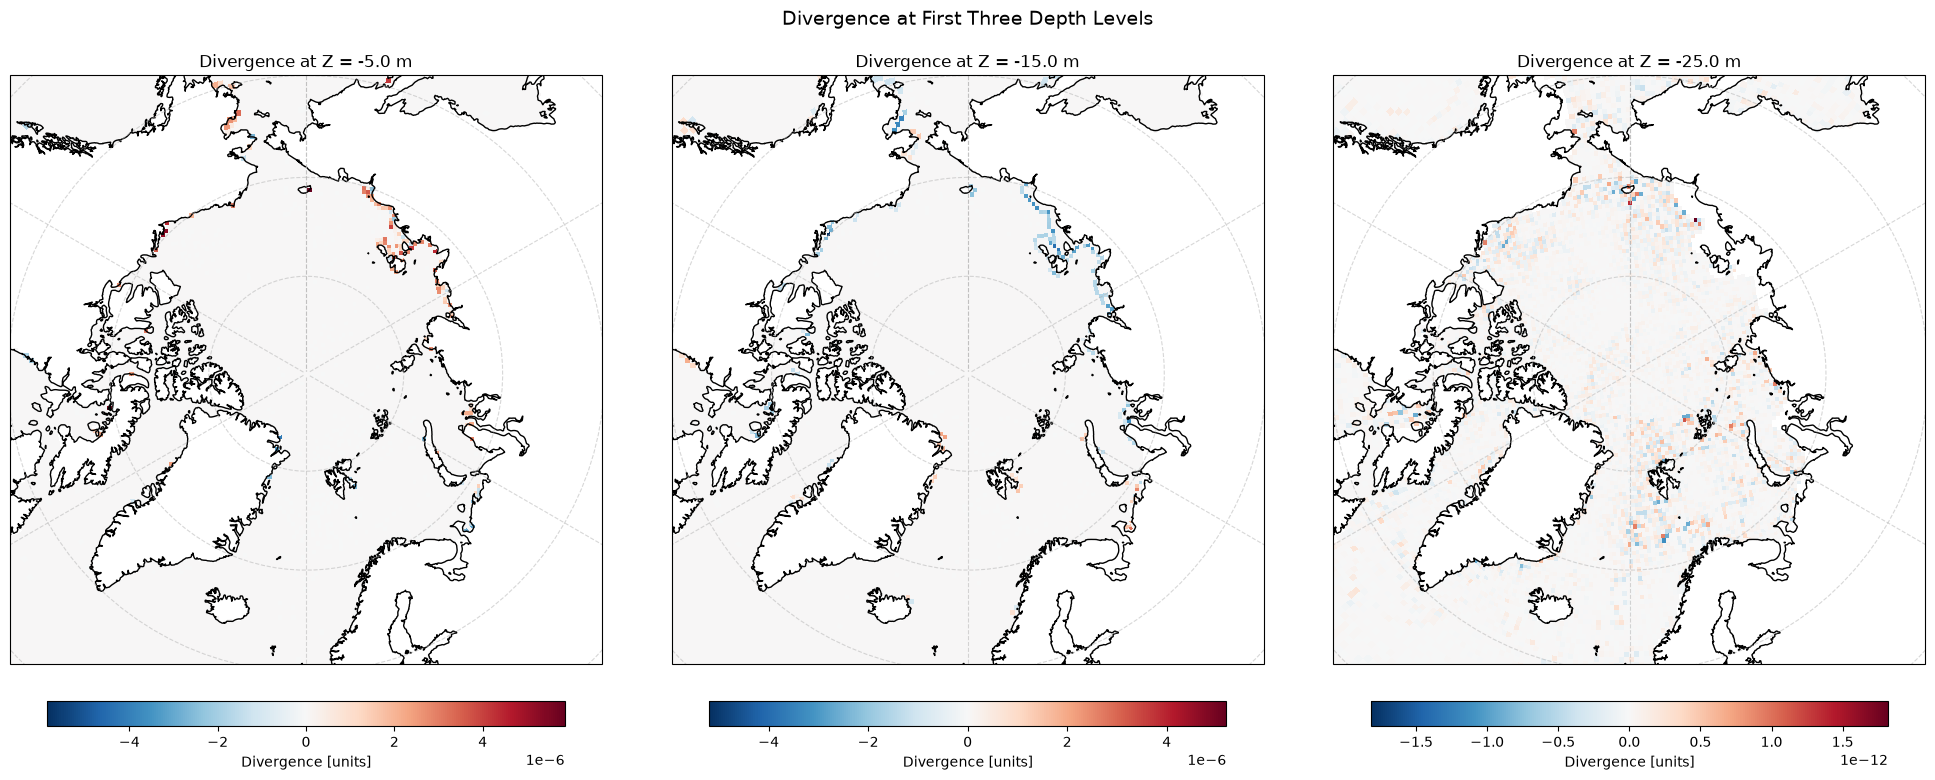

In [15]:
# -----------------------------------
# Plot the divergence
# -----------------------------------

# Select a specific time (t = 0)
div_snapshot = div.isel(time=0)

# Get the first three depth levels
depth_levels = [0, 1, 2]
# Select required faces (for ECCO's LLC grid)
faces = [2, 5, 6, 7, 10]

# Get depth values for labels
depth_values = div.Z.values[:3]

# Begin plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 8), 
                          subplot_kw={'projection': ccrs.NorthPolarStereo()})

for idx, z_level in enumerate(depth_levels):
    ax = axes[idx]
    
    # Get vmin/vmax for this specific depth level
    data_at_level = div_snapshot.isel(Z=z_level)
    vmin = data_at_level.min().values
    vmax = data_at_level.max().values
    # For symmetric colorbar around zero:
    vmax_abs = max(abs(vmin), abs(vmax))
    vmin, vmax = -vmax_abs, vmax_abs
    
    for f in faces:
        # Plot for each face
        pc = ax.pcolormesh(
            ds_day.XC[f, :, :].values,
            ds_day.YC[f, :, :].values,
            div_snapshot.isel(Z=z_level, face=f).values,
            cmap='RdBu_r',
            vmin=vmin,
            vmax=vmax,
            transform=ccrs.PlateCarree(),
            shading='auto')
    
    ax.set_title(f'Divergence at Z = {depth_values[idx]:.1f} m', fontsize=12)
    ax.coastlines()
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=False, linestyle='--', alpha=0.5)
    cbar = fig.colorbar(pc, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
    cbar.set_label(r"Divergence [units]", fontsize=10)

plt.suptitle('Divergence at First Three Depth Levels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The divergence shows some interesting spatial patterns. In the first two depth levels, cells where the total ocean depth is exactly two grid cells have non-zero divergence whose magnitude is much larger than machine precision.

Compare to the third depth level, where the divergence has a magnitude much closer to machine precision and there is no particular spatial pattern to the divergence. 

This points to an issue with the bolus velocity output in ECCOv4r4. Without fixing this issue, some calculations (e.g. Lagrangian particle tracking using `Seaduck`, Reynolds Decomposition of advective terms in the budgets) will be incorrect. This issue is known to the ECCO model team: https://github.com/MITgcm/gcmfaces/issues/21

It turns out that the correct, non-divergent bolus velocity can be calculated from the GM streamfunction output by ECCOv4r4. That is done using the code below:

In [16]:
# ---------------------------------------
# Inspect the GM streamfunction dataset
# ---------------------------------------

strm = xr.open_zarr('/home/idies/workspace/poseidon_ceph/daily_mean_ecco/OCEAN_BOLUS_STREAMFUNCTION_daily.zarr')

strm

<xarray.Dataset> Size: 400GB
Dimensions:    (time: 9496, Zl: 50, face: 13, Y: 90, Xp1: 90, Yp1: 90, X: 90,
                nb: 4, Z: 50, nv: 2, Zp1: 51, Zu: 50)
Coordinates: (12/22)
  * time       (time) datetime64[ns] 76kB 1992-01-01T18:00:00 ... 2017-12-31T...
  * Zl         (Zl) float32 200B 0.0 -10.0 -20.0 ... -5.244e+03 -5.678e+03
    k_l        (Zl) int32 200B dask.array<chunksize=(50,), meta=np.ndarray>
  * face       (face) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * Y          (Y) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * Xp1        (Xp1) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
    ...         ...
    Z_bnds     (Z, nv) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
    time_bnds  (time, nv) datetime64[ns] 152kB dask.array<chunksize=(1, 2), meta=np.ndarray>
  * Zp1        (Zp1) float32 204B 0.0 -10.0 -20.0 ... -5.678e+03 -6.134e+03
    k_p1       (Zp1) int32 204B dask.array<chunksize=(51,), meta=np.ndarray>
  * Zu         (Zu) float32 200B -10.0 -20.0 -30.0 ... -5.678e+03 -6.134e+03
    k_u        (Zu) int32 200B dask.array<chunksize=(50,), meta=np.ndarray>
Dimensions without coordinates: nb, nv
Data variables:
    GM_PsiX    (time, Zl, face, Y, Xp1) float32 200GB dask.array<chunksize=(1, 50, 1, 90, 90), meta=np.ndarray>
    GM_PsiY    (time, Zl, face, Yp1, X) float32 200GB dask.array<chunksize=(1, 50, 1, 90, 90), meta=np.ndarray>
Attributes: (12/62)
    Conventions:                     CF-1.8, ACDD-1.3
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty and Ou Wang
    cdm_data_type:                   Grid
    comment:                         Fields provided on the curvilinear lat-l...
    coordinates_comment:             Note: the global 'coordinates' attribute...
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               1992-01-02T00:00:00
    time_coverage_resolution:        P1D
    time_coverage_start:             1992-01-01T12:00:00
    title:                           ECCO Gent-McWilliams Bolus Transport Str...
    uuid:                            94910faa-4160-11eb-8bb4-0cc47a3f4aa1

In [17]:
# ----------------------------
# Recalculate bolus velocity
# ----------------------------

xgcmgrd = create_ecco_grid(ds_day)

strmx = strm.GM_PsiX.fillna(0)
strmy = strm.GM_PsiY.fillna(0)

u_bol = xgcmgrd.diff(strmx,"Z", boundary = 'fill', fill_value = 0.0)/ds_day.drF
v_bol = xgcmgrd.diff(strmy,"Z", boundary = 'fill', fill_value = 0.0)/ds_day.drF

vstrmx = strmx*ds_day.dyG
vstrmy = strmy*ds_day.dxG

xy_diff = xgcmgrd.diff_2d_vector(
    {"X": vstrmx, "Y": vstrmy}, boundary="fill", fill_value=0.0
)
x_diff = xy_diff["X"]
y_diff = xy_diff["Y"]
hDiv = (x_diff + y_diff) 

w_bol = hDiv/ds_day.rA

In [18]:
# ------------------------------
# Calculate new bolus transport
# ------------------------------

ds_day['utrans_correct'] = (u_bol*ds_day['drF']*ds_day['dyG']).fillna(0)
ds_day['vtrans_correct'] = (v_bol*ds_day['drF']*ds_day['dxG']).fillna(0)
ds_day['wtrans_correct'] = (w_bol*ds_day['rA']).fillna(0)

In [19]:
# --------------------------
# Calculate the divergence
# --------------------------

# For the sake of speed, we will only calculate the bolus velocity
# for the first 10 timesteps.

# The calculation for the full dataset takes several minutes

xgcmgrd = create_ecco_grid(ds_day.isel(time = slice(0,10)), for_outer = True)
bathtub = sd.OceData(ds_day.isel(time=slice(0,10)))

div = total_div(bathtub, xgcmgrd, 'utrans_correct', 'vtrans_correct', 'wtrans_correct')

/home/idies/mambaforge/envs/Oceanography/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


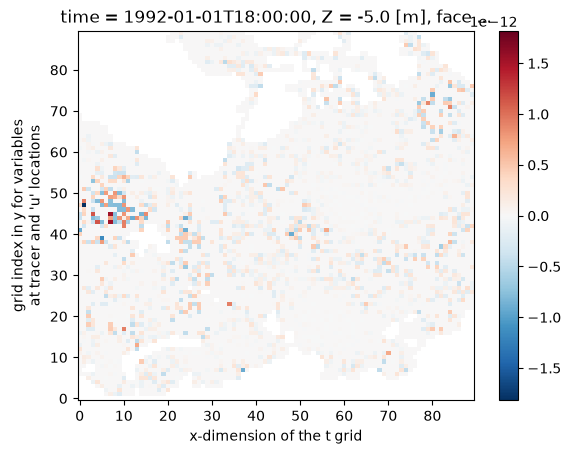

In [20]:
# ---------------------
# Quick plot to check!
# ---------------------

div[0,0,6].plot()

As you can see, we have now created a bolus velocity whose divergence is exactly zero. This is correct! We can safely move forwards with any calculations that involve the bolus velocity.